# Notebook for extracting data for Skew-T plots and generating barcharts

### Import statements

In [ ]:
from netCDF4 import Dataset
import numpy as np
import glob
import os
import scipy
import xarray as xr
import csv
from matplotlib.font_manager import FontProperties
import matplotlib.pyplot as plt
import pandas as pd
from wrf import getvar
from pint import UnitRegistry
import wrf
from netCDF4 import Dataset
import metpy.calc as mpcalc
from metpy.plots import SkewT
from metpy.units import units

### Extracting data for instantaneous Skew-T plots

In [ ]:
units = UnitRegistry()
runs = [1,2,3,4,5]
year = '2024'
names = [f'Cropland_{year}',f'Natland_{year}',f'BEPBEM_GrUrban_{year}',f'BEPBEM_WRFDef_{year}',f'NoUCM_WRFDef_{year}',f'NoUCM_GrUrban_{year}']
for name in names:
    for run in runs:
        if run == 1:
            DIREC = name
            DIR_PATH = f"/g/data/li18/em3807_2/WRF_runs/{name}"
        else:
            DIREC = f"{name}_{run}"
            DIR_PATH = f"/g/data/li18/em3807_2/WRF_runs/{name}_{run}"

        # Define the specific times you want to extract.

        date = '13'

        # DESIRED_TIMES = [
        #     "2017-02-17_22:00:00",
        #     "2017-02-18_01:00:00",
        #     "2017-02-18_04:00:00",
        #     "2017-02-18_07:00:00"
        # ]

        # DESIRED_TIMES = [
        #     "2018-12-19_22:00:00",
        #     "2018-12-20_01:00:00",
        #     "2018-12-20_04:00:00",
        #     "2018-12-20_07:00:00"
        # ]

        # DESIRED_TIMES = [
        #     "2020-12-16_22:00:00",
        #     "2020-12-17_01:00:00",
        #     "2020-12-17_04:00:00",
        #     "2020-12-17_07:00:00"
        # ]

        DESIRED_TIMES = [
            "2024-02-12_22:00:00",
            "2024-02-13_01:00:00",
            "2024-02-13_04:00:00",
            "2024-02-13_07:00:00"
        ]
        data_gridded = [Dataset('/g/data/li18/em3807_2/WRF_runs/BEPBEM_GrUrban_2024/wrfout_d02_2024-02-11_00:00:00')]  
        land = wrf.getvar(data_gridded, 'LU_INDEX', timeidx=0, method='cat')
        # defining the metropolitan area
        urb = np.where(land <= 49, 0, land)
        urb[0:140, 0:200] = 0 # area below Sydney
        urb[0:289, 0:150] = 0 # left of Sydney
        urb[205:289, 0:279] = 0 # left of Sydney

        if __name__ == "__main__":
            print("Starting WRF data processing...")
            print(f"Looking for files in directory: {DIR_PATH}")

            # find domain 2 files
            file_list = sorted(glob.glob(os.path.join(DIR_PATH, "wrfout_d02*")))
            if not file_list:
                print("Error: No 'wrfout_d02*' files found. Exiting.")
                exit()

            all_times = []
            all_p = []
            all_T = []
            all_Td = []
            all_u = []
            all_v = []
            n_levels = 0

            # process WRF files
            for file_path in file_list:
                try:
                    with Dataset(file_path, "r") as ds:
                        file_times = ds.variables['Times'][:]
                        file_times_str = np.array([''.join(c.astype(str)) for c in file_times])
                        # see if desired time is in the dataset
                        for desired_time_str in DESIRED_TIMES:
                            if desired_time_str in file_times_str:
                                # find the index of the time in the dataset
                                time_idx = np.where(file_times_str == desired_time_str)[0][0]
                                variables = [getvar(ds, "pressure", timeidx=time_idx), getvar(ds, "tc", timeidx=time_idx),
                                getvar(ds, "td", timeidx=time_idx), getvar(ds, "ua", timeidx=time_idx),
                                getvar(ds, "va", timeidx=time_idx)]
                                val_arr = []
                                for variable in variables:
                                    val_list = []
                                    for i in range(variables[0].shape[0]):
                                        ind_val = np.nanmean(np.where(urb == 0, np.nan, variable[i,:,:]))
                                        val_list.append(ind_val)
                                    val_arr.append(np.array(val_list))
                                p_profile = val_arr[0]
                                if len(p_profile) > 3:
                                    p_profile[3] = p_profile[3] + 0.02
                                if len(p_profile) > 10:
                                    p_profile[10] = p_profile[10] - 0.01

                                all_times.append(np.datetime64(desired_time_str.replace("_", "T")))
                                all_p.append(p_profile)
                                all_T.append(val_arr[1])
                                all_Td.append(val_arr[2])
                                all_u.append(val_arr[3])
                                all_v.append(val_arr[4])
                                
                                if n_levels == 0:
                                    n_levels = len(p_profile)

            # write to a netcdf file
            output_filename = os.path.join('/g/data/li18/em3807_2/WRF_runs/Skew-T', DIREC+"_"+date+"_urban_skewt.nc")
            if not all_p:
                print("No data was extracted. Exiting without creating a NetCDF file.")
                exit()
            
            with Dataset(output_filename, 'w', format='NETCDF4') as fout:
                fout.createDimension('time', None)  # Unlimited dimension
                fout.createDimension('level', n_levels)

                time_var = fout.createVariable('time', 'f8', ('time',))
                pressure_var = fout.createVariable('pressure', 'f4', ('time', 'level',))
                T_var = fout.createVariable('T', 'f4', ('time', 'level',))
                Td_var = fout.createVariable('Td', 'f4', ('time', 'level',))
                u_var = fout.createVariable('u', 'f4', ('time', 'level',))
                v_var = fout.createVariable('v', 'f4', ('time', 'level',))

                fout.description = "WRF point data extracted via Python script with netCDF4"
                fout.created_by = "Python Script with netCDF4 and wrf-python"

                # add in units
                pressure_var.units = "hPa"
                T_var.units = "degC"
                Td_var.units = "degC"
                u_var.units = "m/s"
                v_var.units = "m/s"
                
                # define a reference time so that the files can be opened in ncview 
                ref_time = np.datetime64('2020-12-16T00:00:00')
                seconds_since_ref = (np.array(all_times) - ref_time).astype('timedelta64[s]').astype(float)
                
                time_var.units = "seconds since 2017-02-18 00:00:00"
                time_var.long_name = "time of data"
                
                time_var[:] = seconds_since_ref
                pressure_var[:] = np.array(all_p)
                T_var[:] = np.array(all_T)
                Td_var[:] = np.array(all_Td)
                u_var[:] = np.array(all_u)
                v_var[:] = np.array(all_v)

            print(f"Done. Skew-T '{output_filename}' has been created.")

### Extracting skew-T data for pre-storm Skew-T averages

In [ ]:
import numpy as np
import glob
import os
from netCDF4 import Dataset
from wrf import getvar
import pandas as pd
from pint import UnitRegistry  # <-- you need to import this

ureg = UnitRegistry()

date = '20'
runs = [1,2,3,4,5]
year = '2017'
setup = [f'Cropland_{year}', f'Natland_{year}', f'NoUCM_GrUrban_{year}', f'NoUCM_WRFDef_{year}', f'BEPBEM_GrUrban_{year}', f'BEPBEM_WRFDef_{year}']

for name in setup:
    for run in runs:
        if run == 1:
            DIREC = name
            DIR_PATH = f"/g/data/li18/em3807_2/WRF_runs/{name}"
        else:
            DIREC = f"{name}_{run}"
            DIR_PATH = f"/g/data/li18/em3807_2/WRF_runs/{name}_{run}"

        data_gridded = [Dataset('/g/data/li18/em3807_2/WRF_runs/BEPBEM_GrUrban_2024/wrfout_d02_2024-02-11_00:00:00')]
        land = getvar(data_gridded, 'LU_INDEX', timeidx=0, method='cat')

        # averaging only over the metropolitan
        urb = np.where(land <= 49, 0, land)
        urb[0:140, 0:200] = 0  # area below Sydney
        urb[0:289, 0:150] = 0  # left of Sydney
        urb[205:289, 0:279] = 0  # left of Sydney

        if __name__ == "__main__":
            print("Starting WRF data processing...")
            print(f"Looking for files in directory: {DIR_PATH}")

            file_list = sorted(glob.glob(os.path.join(DIR_PATH, "wrfout_d02*")))
            if not file_list:
                print("Error: No 'wrfout_d02*' files found. Exiting.")
                exit()
            pre_storm_start = pd.to_datetime("2017-02-17 22:00:00")
            pre_storm_end   = pd.to_datetime("2017-02-17 23:00:00")
            peak_storm_start = pd.to_datetime("2017-02-18 09:00:00")
            peak_storm_end   = pd.to_datetime("2017-02-18 10:00:00")

            # pre_storm_start = pd.to_datetime("2018-12-20 00:30:00")
            # pre_storm_end   = pd.to_datetime("2018-12-20 01:30:00")
            # peak_storm_start = pd.to_datetime("2018-12-20 06:00:00")
            # peak_storm_end   = pd.to_datetime("2018-12-20 07:00:00")

            # pre_storm_start = pd.to_datetime("2020-12-16 19:00:00")
            # pre_storm_end   = pd.to_datetime("2020-12-16 20:00:00")
            # peak_storm_start = pd.to_datetime("2020-12-17 04:00:00")
            # peak_storm_end   = pd.to_datetime("2020-12-17 05:00:00")

            # pre_storm_start = pd.to_datetime("2024-02-12 23:00:00")
            # pre_storm_end   = pd.to_datetime("2024-02-13 00:00:00")
            # peak_storm_start = pd.to_datetime("2024-02-13 03:30:00")
            # peak_storm_end   = pd.to_datetime("2024-02-13 04:30:00")

            # generate WRF time steps between the pre and peak ranges
            pre_storm_times = pd.date_range(pre_storm_start, pre_storm_end, freq="10min")
            peak_storm_times = pd.date_range(peak_storm_start, peak_storm_end, freq="10min")

            def dt_to_str(dt):
                return dt.strftime("%Y-%m-%d_%H:%M:%S")

            pre_storm_times_str = [dt_to_str(dt) for dt in pre_storm_times]
            peak_storm_times_str = [dt_to_str(dt) for dt in peak_storm_times]

            pre_storm_data = {"times": [], "pressure": [], "T": [], "Td": [], "u": [], "v": []}
            peak_storm_data = {"times": [], "pressure": [], "T": [], "Td": [], "u": [], "v": []}
            n_levels = 0

            for file_path in file_list:
                try:
                    with Dataset(file_path, "r") as ds:
                        file_times = ds.variables['Times'][:]
                        file_times_str = np.array([''.join(c.astype(str)) for c in file_times])

                        for desired_time_str in pre_storm_times_str + peak_storm_times_str:
                            if desired_time_str in file_times_str:
                                time_idx = np.where(file_times_str == desired_time_str)[0][0]

                                vars_to_get = [
                                    getvar(ds, "pressure", timeidx=time_idx),
                                    getvar(ds, "tc", timeidx=time_idx),
                                    getvar(ds, "td", timeidx=time_idx),
                                    getvar(ds, "ua", timeidx=time_idx),
                                    getvar(ds, "va", timeidx=time_idx),
                                ]
                                val_arr = []
                                for var in vars_to_get:
                                    profile = []
                                    for lev in range(var.shape[0]):
                                        arr2d = var[lev, :, :]
                                        masked = np.where(urb == 0, np.nan, arr2d)
                                        mean_val = np.nanmean(masked)
                                        profile.append(mean_val)
                                    val_arr.append(np.array(profile))

                                if desired_time_str in pre_storm_times_str:
                                    target = pre_storm_data
                                else:
                                    target = peak_storm_data

                                target["times"].append(np.datetime64(desired_time_str.replace("_", "T")))
                                target["pressure"].append(p_profile)
                                target["T"].append(val_arr[1])
                                target["Td"].append(val_arr[2])
                                target["u"].append(val_arr[3])
                                target["v"].append(val_arr[4])

                                if n_levels == 0:
                                    n_levels = len(p_profile)
                except Exception as e:
                    print(f"Error processing file {os.path.basename(file_path)}: {e}")

            all_times = np.array(pre_storm_data["times"] + peak_storm_data["times"])
            all_pressure = np.array(pre_storm_data["pressure"] + peak_storm_data["pressure"])
            all_T = np.array(pre_storm_data["T"] + peak_storm_data["T"])
            all_Td = np.array(pre_storm_data["Td"] + peak_storm_data["Td"])
            all_u = np.array(pre_storm_data["u"] + peak_storm_data["u"])
            all_v = np.array(pre_storm_data["v"] + peak_storm_data["v"])

            labels = ["pre"] * len(pre_storm_data["times"]) + ["peak"] * len(peak_storm_data["times"])

            # write to a netcdf file
            output_filename = os.path.join('/g/data/li18/em3807_2/WRF_runs/Skew-T',
                                        f"{DIREC}_{date}_prepeak_skewt.nc")

            with Dataset(output_filename, 'w', format='NETCDF4') as fout:
                fout.createDimension('time', None)
                fout.createDimension('level', n_levels)

                time_var = fout.createVariable('time', 'f8', ('time',))
                pressure_var = fout.createVariable('pressure', 'f4', ('time', 'level'))
                T_var = fout.createVariable('T', 'f4', ('time', 'level'))
                Td_var = fout.createVariable('Td', 'f4', ('time', 'level'))
                u_var = fout.createVariable('u', 'f4', ('time', 'level'))
                v_var = fout.createVariable('v', 'f4', ('time', 'level'))
                label_var = fout.createVariable('stage', str, ('time',))  # label: pre or post

                fout.description = "WRF pre‑storm and peak‑storm point data"
                fout.created_by = "Python script with netCDF4 and wrf‑python"

                pressure_var.units = "hPa"
                T_var.units = "degC"
                Td_var.units = "degC"
                u_var.units = "m/s"
                v_var.units = "m/s"

                ref_time = all_times.min()
                seconds_since_ref = (all_times - ref_time).astype('timedelta64[s]').astype(float)

                time_var.units = f"seconds since {ref_time.astype('datetime64[s]')}"
                time_var.long_name = "time"

                time_var[:] = seconds_since_ref
                pressure_var[:, :] = all_pressure
                T_var[:, :]        = all_T
                Td_var[:, :]       = all_Td
                u_var[:, :]        = all_u
                v_var[:, :]        = all_v
                label_var[:] = np.array(labels, dtype=object)

            print(f"Done. File '{output_filename}' has been created.")


### Creating barchart data

In [ ]:
import xarray as xr
import numpy as np
import metpy.calc as mpcalc
from metpy.units import units

# names
mains = ['Cropland','Natland','NoUCM_GrUrban','BEPBEM_GrUrban','NoUCM_WRFDef','BEPBEM_WRFDef']
for name_main in mains:
    name_crop = 'Cropland'
    year = '2020'
    date = '17'
    print(name_main)
    shrs = []

    # defining files for the cropland and comparison setup
    ensemble_main_files = [
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_main}_{year}_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_main}_{year}_2_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_main}_{year}_3_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_main}_{year}_4_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_main}_{year}_5_{date}_urban_prepeak_skewt.nc",
    ]

    ensemble_crop_files = [
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_crop}_{year}_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_crop}_{year}_2_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_crop}_{year}_3_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_crop}_{year}_4_{date}_urban_prepeak_skewt.nc",
        f"/g/data/li18/em3807_2/WRF_runs/Skew-T/{name_crop}_{year}_5_{date}_urban_prepeak_skewt.nc",
    ]

    ensemble_names = ["ens1","ens2","ens3","ens4","ens5"]

    metrics = ["cape", "cin", "bulk_shear", "surf_dewpoint", "ground_temp"]

    def safe_mean(arr, mask):
        if np.any(mask):
            return np.nanmean(arr[mask])
        else:
            return np.nan

    def compute_metrics(ds):
        p_arr  = ds['pressure'].values * units.hPa
        T_arr  = ds['T'].values * units.degC
        Td_arr = ds['Td'].values * units.degC
        u_arr  = ds['u'].values * units('m/s')
        v_arr  = ds['v'].values * units('m/s')
        stage  = ds['stage'].values  # array of "pre" / "post"

        surf_dewpoint_arr = Td_arr[:,0].magnitude
        ground_temp_arr   = T_arr[:,0].magnitude
        ntime, nlevel = p_arr.shape

        cape_arr   = np.full(ntime, np.nan, dtype=float)
        cin_arr    = np.full(ntime, np.nan, dtype=float)
        shear_arr  = np.full(ntime, np.nan, dtype=float)
        u_bot_arr = np.full(ntime, np.nan, dtype=float)
        u_top_arr = np.full(ntime, np.nan, dtype=float)
        v_bot_arr = np.full(ntime, np.nan, dtype=float)
        v_top_arr = np.full(ntime, np.nan, dtype=float) 

        for ti in range(ntime):
            p_prof  = p_arr[ti, :]
            T_prof  = T_arr[ti, :]
            Td_prof = Td_arr[ti, :]
            u_prof  = u_arr[ti, :]
            v_prof  = v_arr[ti, :]

            if np.all(np.isnan(p_prof)) or np.all(np.isnan(T_prof)):
                continue
            try:
                ml_cape, ml_cin = mpcalc.mixed_layer_cape_cin(
                    p_prof, T_prof, Td_prof, depth=50 * units.hPa
                )
                cape_arr[ti] = ml_cape.to('J/kg').magnitude
                cin_arr[ti]  = ml_cin.to('J/kg').magnitude
            except Exception as e:
                print(f"   CAPE/CIN error at time {ti}: {e}")

            # Bulk shear
            try:
                ub, vb = mpcalc.bulk_shear(
                    p_prof, u_prof, v_prof,
                    depth=6000 * units.meters, bottom=p_prof[0]
                )
                shear_arr[ti] = mpcalc.wind_speed(ub, vb).to('m/s').magnitude
            except Exception as e:
                print(f"   Shear error at time {ti}: {e}")

        mask_pre  = (stage == "pre")
        mask_peak = (stage == "peak")

        out = {}
        out['cape'] = {
            "pre": safe_mean(cape_arr, mask_pre),
            "peak": safe_mean(cape_arr, mask_peak)
        }
        out['cin'] = {
            "pre": safe_mean(cin_arr, mask_pre),
            "peak": safe_mean(cin_arr, mask_peak)
        }
        out['bulk_shear'] = {
            "pre": safe_mean(shear_arr, mask_pre),
            "peak": safe_mean(shear_arr, mask_peak)
        }

        out['surf_dewpoint'] = {
            "pre": np.nanmean(surf_dewpoint_arr[mask_pre]),
            "peak": np.nanmean(surf_dewpoint_arr[mask_peak])
        }
        out['ground_temp'] = {
            "pre": np.nanmean(ground_temp_arr[mask_pre]),
            "peak": np.nanmean(ground_temp_arr[mask_peak])
        }

        return out

    diff_abs = {m: {"pre": [], "peak": []} for m in metrics}
    diff_pct = {m: {"pre": [], "peak": []} for m in metrics}

    for fname_main, fname_crop, ename in zip(ensemble_main_files, ensemble_crop_files, ensemble_names):
        ds_main = xr.open_dataset(fname_main)
        ds_crop = xr.open_dataset(fname_crop)

        metrics_main = compute_metrics(ds_main)
        metrics_crop = compute_metrics(ds_crop)

        for m in metrics:
            for stage_label in ["pre", "peak"]:
                val_main = metrics_main[m][stage_label]
                val_crop = metrics_crop[m][stage_label]
                if m == 'bulk_shear' and stage_label == 'pre':
                    shrs.append(val_main) # Stores the average shear for each setup
                diff = val_main - val_crop
                diff_abs[m][stage_label].append(diff)

                if (val_crop is None) or np.isnan(val_crop) or val_crop == 0:
                    pct = np.nan
                else:
                    pct = 100.0 * diff / val_crop
                diff_pct[m][stage_label].append(pct)
    print(f'Average shear is {np.mean(shrs)}')
    print(f'Standard deviation is {np.std(shrs)}')
    summary_abs = {}
    summary_pct = {}
    for m in metrics:
        summary_abs[m] = {}
        summary_pct[m] = {}
        for stage_label in ["pre", "peak"]:
            arr_abs = np.array( diff_abs[m][stage_label] )
            arr_pct = np.array( diff_pct[m][stage_label] )

            summary_abs[m][stage_label] = {
                "min":   np.nanmin(arr_abs),
                "mean":  np.nanmean(arr_abs),
                "max":   np.nanmax(arr_abs),
                "all_members": arr_abs
            }
            summary_pct[m][stage_label] = {
                "min":   np.nanmin(arr_pct),
                "mean":  np.nanmean(arr_pct),
                "max":   np.nanmax(arr_pct),
                "all_members": arr_pct
            }

    # save to netcdf

    rows = []
    for m in metrics:
        for stage_label in ["pre", "peak"]:
            d_abs = summary_abs[m][stage_label]
            d_pct = summary_pct[m][stage_label]
            rows.append({
                "metric":       m,
                "stage":        stage_label,
                "abs_min":      d_abs["min"],
                "abs_mean":     d_abs["mean"],
                "abs_max":      d_abs["max"],
                "pct_min":      d_pct["min"],
                "pct_mean":     d_pct["mean"],
                "pct_max":      d_pct["max"],
            })

    # import pandas as pd
    # df = pd.DataFrame(rows)

    # ds_out = xr.Dataset.from_dataframe(df.set_index(["metric","stage"]))

    # out_nc = f"/home/561/em3807/honours-project/Average_bardata/{name_main}_vs_{name_crop}_{year}_peak.nc"
    # ds_out.to_netcdf(out_nc, mode='w', format='NETCDF4')
    # print(f"Written difference summary (with surface & ground) to {out_nc}")

### Skew-T plot

In [ ]:
setup_name = 'NoUCM_WRFDef_2018'
# date = '18/02/2017'
date = '20/12/2018'
# date = '17/12/2020'
# date = '13/02/2024'

times = ['9am', '12pm', '3pm', '6pm']

# load in files
files = [f'/g/data/li18/em3807_2/WRF_runs/Skew-T/{setup_name}_{date[0:2]}_urban_skewt.nc',
f'/g/data/li18/em3807_2/WRF_runs/Skew-T/{setup_name}_2_{date[0:2]}_urban_skewt.nc',
f'/g/data/li18/em3807_2/WRF_runs/Skew-T/{setup_name}_3_{date[0:2]}_urban_skewt.nc',
f'/g/data/li18/em3807_2/WRF_runs/Skew-T/{setup_name}_4_{date[0:2]}_urban_skewt.nc',
f'/g/data/li18/em3807_2/WRF_runs/Skew-T/{setup_name}_5_{date[0:2]}_urban_skewt.nc'
]

T_list = []
p_list = []
Td_list = []
u_list = []
v_list = []

for file in files:
    ds = xr.open_dataset(file, engine = 'netcdf4')
    if file == '/g/data/li18/em3807_2/WRF_runs/Skew-T/BEPBEM_WRFDef_2018_20_urban_skewt.nc':
        T_list.append(ds['T'][1:])
        p_list.append(ds['pressure'][1:])
        Td_list.append(ds['Td'][1:])
        u_list.append(ds['u'][1:])
        v_list.append(ds['v'][1:])
    else:
        T_list.append(ds['T'])
        p_list.append(ds['pressure'])
        Td_list.append(ds['Td'])
        u_list.append(ds['u'])
        v_list.append(ds['v'])

# Plotting for each time index in ranges list
ranges = [1]
for time_ind in ranges:
    fig = plt.figure(figsize=(6, 9), dpi = 300)
    skew = SkewT(fig,rotation=45)
    # Taking ensemble-averages
    T = np.mean([item[time_ind] for item in T_list], axis=0) * units.degC
    T_lims = [np.min([item[time_ind] for item in T_list], axis=0), np.max([item[time_ind] for item in T_list], axis=0)] * units.degC
    Td = np.mean([item[time_ind] for item in Td_list], axis=0) * units.degC
    Td_lims = [np.min([item[time_ind] for item in Td_list], axis=0), np.max([item[time_ind] for item in Td_list], axis=0)] * units.degC
    p = np.mean([item[time_ind] for item in p_list], axis=0) * units.hPa
    u = np.mean([item[time_ind] for item in u_list], axis=0) * units('m/s')
    v = np.mean([item[time_ind] for item in v_list], axis=0) * units('m/s')
    # Plotting environmental temp
    skew.plot(p, T, 'r')
    t_low = skew.plot(p, T_lims[0], 'r', alpha = 0)[0].get_xdata()
    t_high = skew.plot(p, T_lims[1], 'r', alpha = 0)[0].get_xdata()
    plt.fill_betweenx(p, t_low, t_high, facecolor='r', alpha=0.4)
    # Plotting dew point temp
    skew.plot(p, Td, 'b')
    td_low = skew.plot(p, Td_lims[0], 'b', alpha=0)[0].get_xdata()
    td_high = skew.plot(p, Td_lims[1], 'b', alpha=0)[0].get_xdata()
    plt.fill_betweenx(p, td_low, td_high, facecolor='b', alpha=0.4)

    skew.plot_barbs(p, u, v)

    # Plotting test parcel
    prof = mpcalc.parcel_profile(p, T[0], Td[0])
    skew.plot(p, prof, 'k', linewidth=2)

    # Calculate mixed layer values and shear
    ml_t, ml_td = mpcalc.mixed_layer(p, T, Td, depth=50 * units.hPa)
    mlcape, mlcin = mpcalc.mixed_layer_cape_cin(p, T, Td, depth=50 * units.hPa)
    ubshr, vbshr = mpcalc.bulk_shear(p,u,v,depth = 6000* units.meters, bottom = p[0])
    bshear = mpcalc.wind_speed(ubshr, vbshr)
    plt.text(0.55, 0.71, f'MLCAPE: {mlcape:.0f~P}\nMLCIN: {mlcin:.0f~P}\nSHR06: {bshear:.2f~P}', #0.29, 0.41
            transform=fig.transFigure, fontsize=12, color='black', ha='left',
            bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=1, alpha=1))
    skew.ax.set_ylim(1000, 200)
    skew.ax.set_xlim(-10, 40)
    skew.ax.set_xlabel('Temperature ($^\circ$C)', fontsize=10)
    skew.ax.set_ylabel('Pressure (hPa)', fontsize=10)
    plt.show()
    plt.close(fig)


### Barchart plots

In [7]:
# Files containing hail variable data (calculated from hail statistics script)
direc = os.getcwd()
mhail = pd.read_csv(f'{direc}/hail_barchart_data/Max hail size.csv')
totcov = pd.read_csv(f'{direc}/hail_barchart_data/Total coverage (%).csv')
urbcov = pd.read_csv(f'{direc}/hail_barchart_data/Urban coverage (%).csv')

# Make dictionary from data in files
def dict_maker(df,year):
    years = {'2017':[1,6],
             '2018':[6,11],
             '2020':[11,16],
             '2024':[16,21]}
    indices = years[year]
    data_dict = {'Cropland': df.iloc[0].values[indices[0]:indices[1]],
                 'Forest': df.iloc[1].values[indices[0]:indices[1]],
                 'Gridded No-UCM': df.iloc[2].values[indices[0]:indices[1]],
                 'Gridded BEP-BEM': df.iloc[3].values[indices[0]:indices[1]],
                 'Default No-UCM': df.iloc[4].values[indices[0]:indices[1]],
                 'Default BEP-BEM': df.iloc[5].values[indices[0]:indices[1]]}
    return data_dict
    
max_size_17 = dict_maker(mhail,'2017')
max_size_18 = dict_maker(mhail,'2018')
max_size_20 = dict_maker(mhail,'2020')
max_size_24 = dict_maker(mhail,'2024')
tot_cov_17 = dict_maker(totcov,'2017')
tot_cov_18 = dict_maker(totcov,'2018')
tot_cov_20 = dict_maker(totcov,'2020')
tot_cov_24 = dict_maker(totcov,'2024')
urb_cov_17 = dict_maker(urbcov,'2017')
urb_cov_18 = dict_maker(urbcov,'2018')
urb_cov_20 = dict_maker(urbcov,'2020')
urb_cov_24 = dict_maker(urbcov,'2024')

# Calculate percentage differences for bar plots
def calc_bars(dict):
    crop = np.array(dict['Cropland'])
    case_labels = ['Forest', 
                'Default No-UCM', 'Default BEP-BEM','Gridded No-UCM', 'Gridded BEP-BEM']
    mins = []
    maxs = []
    avgs = []
    for setup in case_labels:
        diff = 100*(np.array(crop)-np.array(dict[setup]))/np.array(crop)
        min = np.min(diff)
        mins.append(min)
        max = np.max(diff)
        maxs.append(max)
        avg = np.mean(diff)
        avgs.append(avg)

    return mins, avgs, maxs

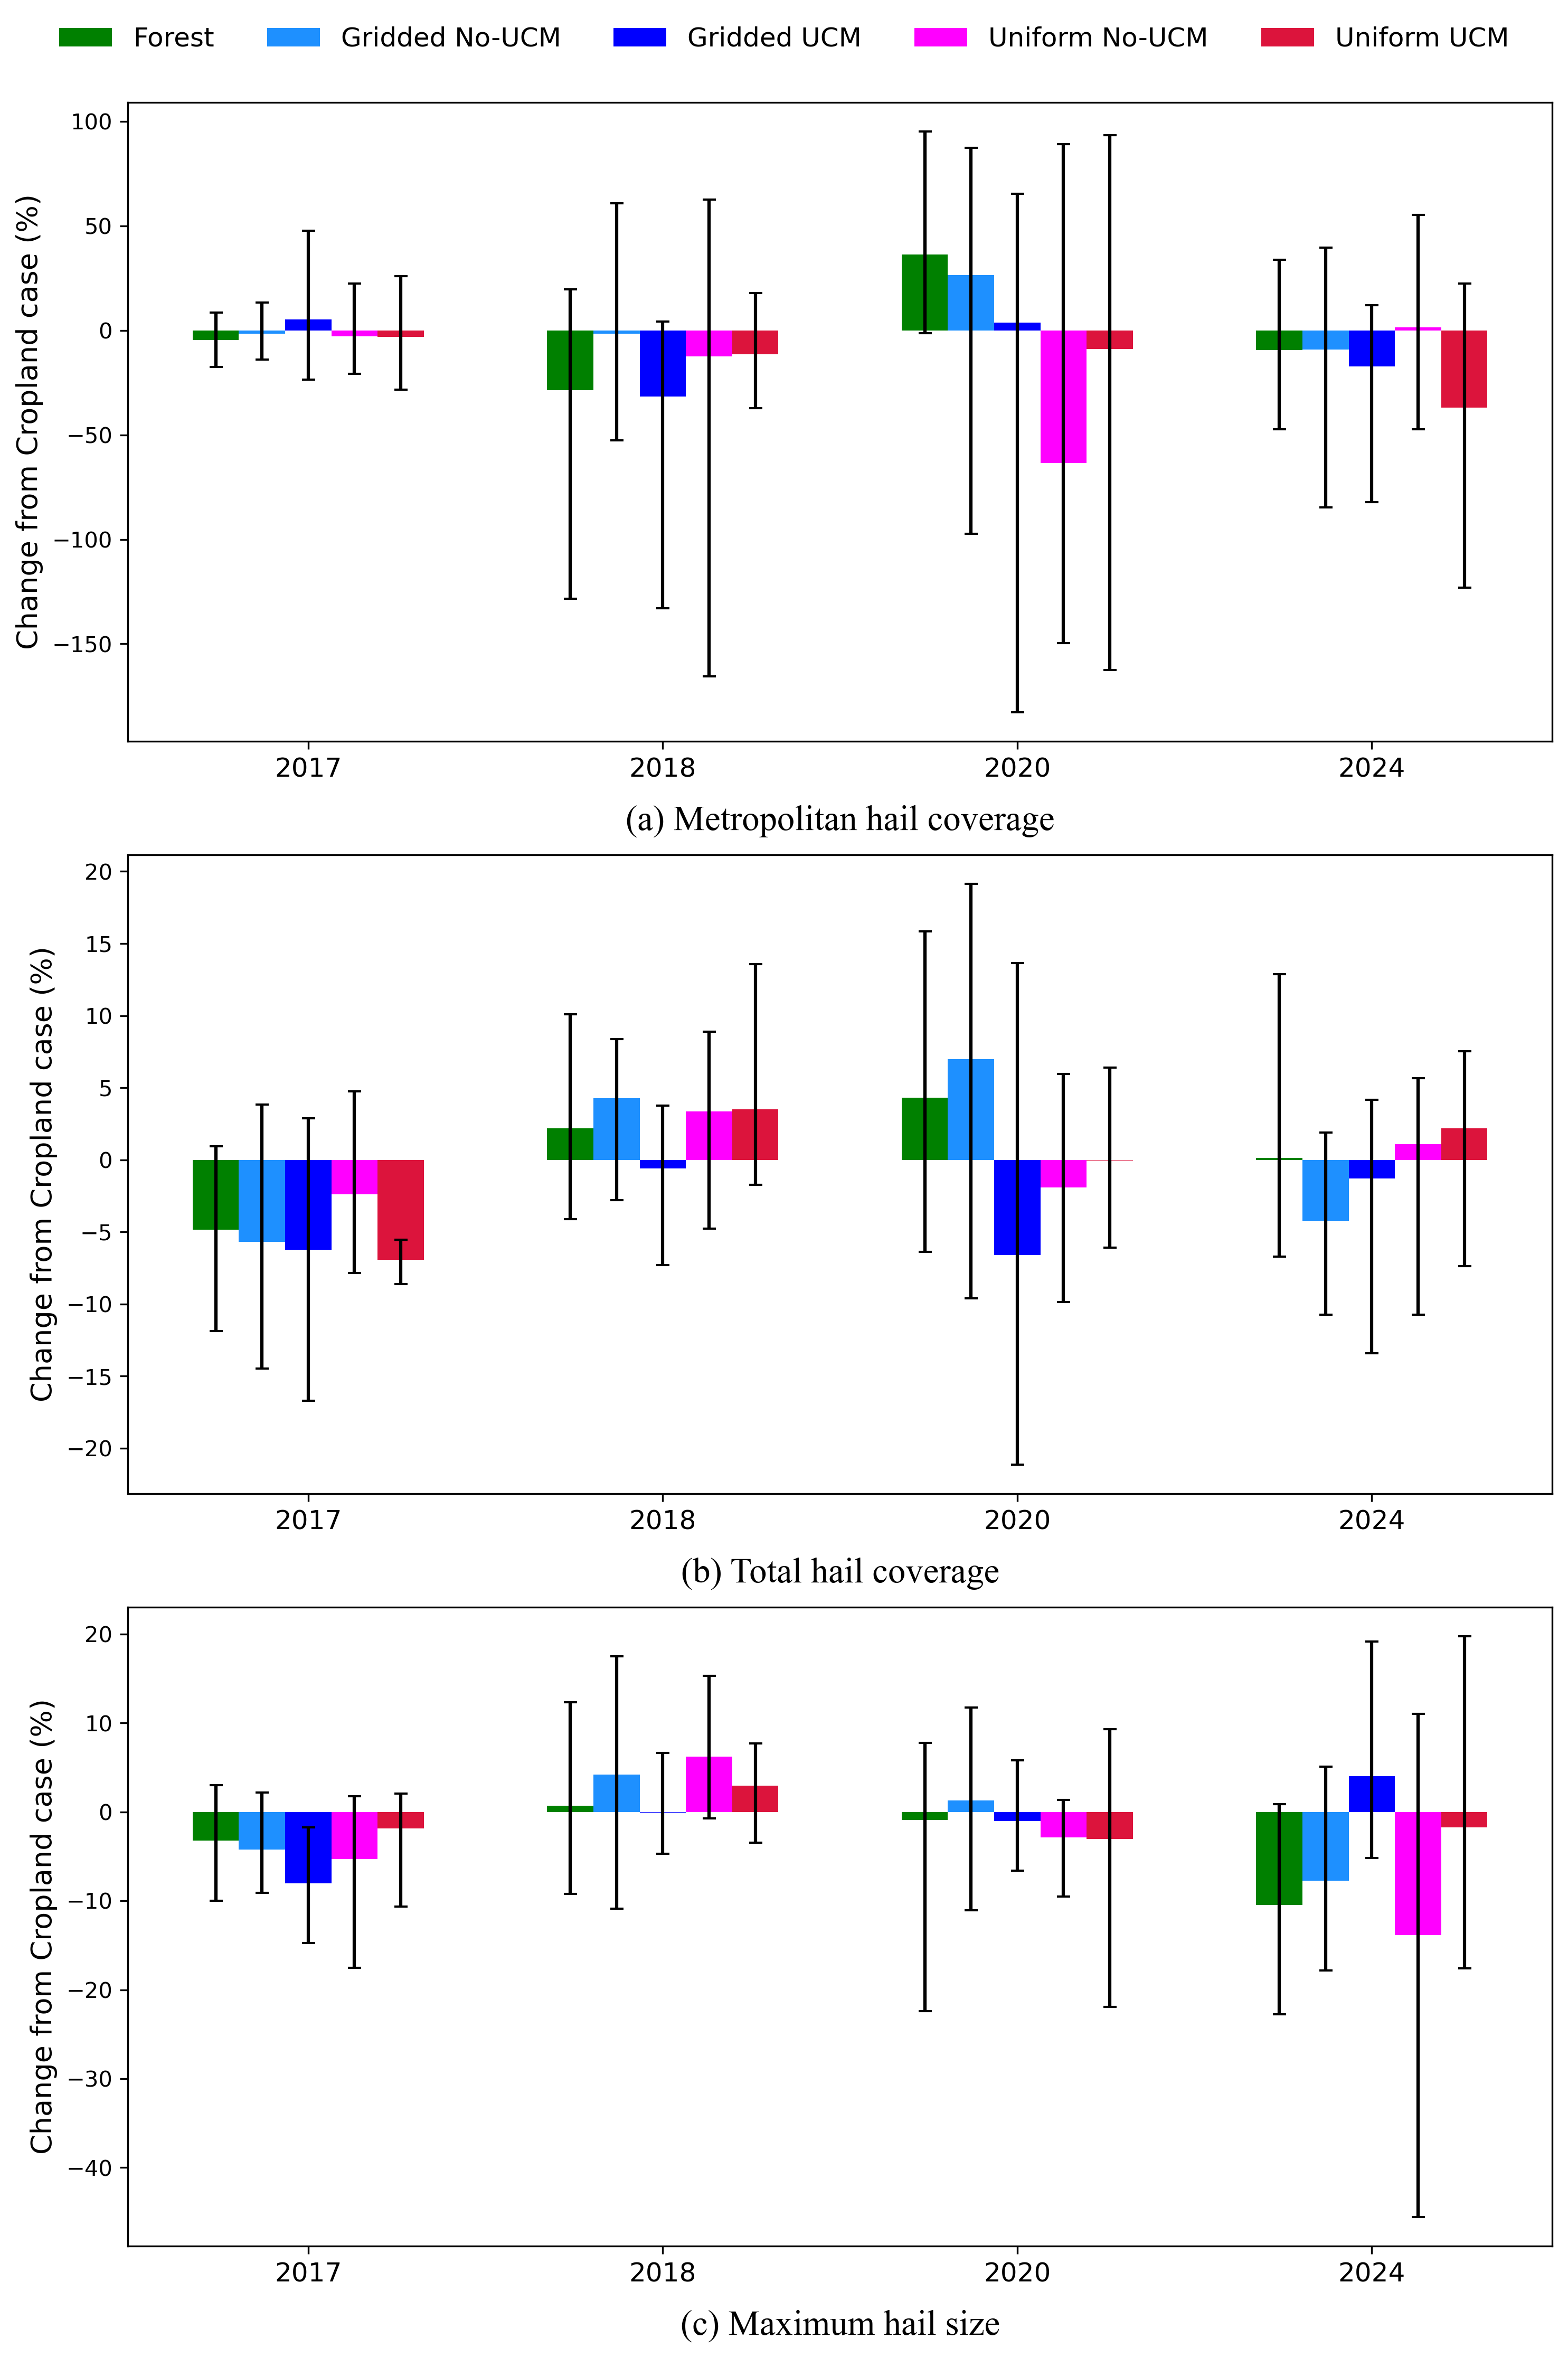

In [8]:
# Plot barchart for hail variables
case_labels = ['Forest', 'Gridded No-UCM', 'Gridded UCM', 'Uniform No-UCM', 'Uniform UCM']
colours = ['green', 'dodgerblue', 'blue', 'magenta', 'crimson']
plot_names = ['Metropolitan Hail Coverage', 'Total Hail Coverage', 'Maximum Hail Size']
time_labels = ['2017', '2018', '2020', '2024']
sub_labels = ['(a) Metropolitan hail coverage', '(b) Total hail coverage', '(c) Maximum hail size']

variables = [urb_cov_17, urb_cov_18, urb_cov_20, urb_cov_24, 
             tot_cov_17, tot_cov_18, tot_cov_20, tot_cov_24, 
             max_size_17, max_size_18, max_size_20, max_size_24]

bar_width = 0.15 
group_gap = 0.4 

fig, axd = plt.subplot_mosaic([['Met'], ['Tot'], ['Max']], 
                              figsize=(10, 16), dpi=300)

mosaic_keys = ['Met', 'Tot', 'Max']

for p_idx, key in enumerate(mosaic_keys):
    ax = axd[key]
    start_idx = p_idx * 4
    current_vars = variables[start_idx : start_idx + 4]
    
    xtick_positions = []

    for v_idx, variable in enumerate(current_vars):
        x_base = v_idx * (5 * bar_width + group_gap) 
        
        for i in range(5):
            stats = calc_bars(variable)
            low, avgval, high = stats[0][i], stats[1][i], stats[2][i]

            y_error = [[np.abs(avgval - low)], [np.abs(high - avgval)]]
            bar_pos = x_base + i * bar_width

            # No outlines on bars
            ax.bar(bar_pos, avgval, yerr=y_error, capsize=3,
                   width=bar_width, color=colours[i], edgecolor='none',
                   label=case_labels[i] if (p_idx == 0 and v_idx == 0) else "")

        xtick_positions.append(x_base + (2 * bar_width))

    # ax.set_title(plot_names[p_idx], fontsize=16, fontweight='bold', pad=15)
    ax.set_xticks(xtick_positions)
    ax.set_xticklabels(time_labels, fontsize=12)
    ax.set_ylabel("Change from Cropland case (%)", fontsize=13)
    font = FontProperties(family='Times New Roman')
    # Subplot labels: (a), (b), (c) 
    ax.text(0.5, -0.1, f"{sub_labels[p_idx]}", transform=ax.transAxes, 
            fontsize=16, va='top', ha='center',fontproperties=font)

fig.legend(case_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=5, fontsize=12, frameon=False)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

In [ ]:
font = FontProperties(family='Times New Roman')
plot_names_dict = {
    'ground_temp': '2 m air temperature',
    'surf_dewpoint': '2 m dewpoint temperature',
    'cape': 'MLCAPE',
    'bulk_shear': '0-6km bulk vertical wind shear'
}
direc = os.getcwd()
variables = list(plot_names_dict.keys())
years = [2017, 2018, 2020, 2024]
case_labels = ['Forest', 'Gridded No-UCM', 'Gridded UCM', 'Uniform No-UCM', 'Uniform UCM']
colours = ['green', 'dodgerblue', 'blue', 'magenta', 'crimson']
sub_labels = ['a', 'b', 'c', 'd']

bar_width = 0.12
year_gap = 0.3 

fig, axd = plt.subplot_mosaic([['ground_temp'], ['surf_dewpoint'], 
                               ['cape'], ['bulk_shear']], 
                              figsize=(10, 16), dpi=300)

for v_idx, var_key in enumerate(variables):
    ax = axd[var_key]
    p_name = plot_names_dict[var_key]
    
    xtick_positions = []

    for y_idx, year in enumerate(years):
        # Data loading logic
        defurb = xr.open_dataset(f'{direc}/Average_bardata/BEPBEM_WRFDef_vs_Cropland_{year}_peak.nc')
        defn = xr.open_dataset(f'{direc}/Average_bardata/NoUCM_WRFDef_vs_Cropland_{year}_peak.nc')
        gr = xr.open_dataset(f'{direc}/Average_bardata/NoUCM_GrUrban_vs_Cropland_{year}_peak.nc')
        grurb = xr.open_dataset(f'{direc}//Average_bardata/BEPBEM_GrUrban_vs_Cropland_{year}_peak.nc')
        nat = xr.open_dataset(f'{direc}//Average_bardata/Natland_vs_Cropland_{year}_peak.nc')

        cases = [nat, gr, grurb, defn, defurb]
        x_base = y_idx * (len(cases) * bar_width + year_gap)

        for i, case in enumerate(cases):
            avgval = case['pct_mean'].sel(metric=var_key, stage='pre').item()
            low = case['pct_min'].sel(metric=var_key, stage='pre').item()
            high = case['pct_max'].sel(metric=var_key, stage='pre').item()

            y_error = [[np.abs(avgval - low)], [np.abs(high - avgval)]]
            bar_pos = x_base + i * bar_width

            ax.bar(bar_pos, avgval, yerr=y_error, capsize=3,
                   width=bar_width, color=colours[i], edgecolor='none',
                   label=case_labels[i] if (v_idx == 0 and y_idx == 0) else "")

        xtick_positions.append(x_base + (len(cases)-1) * bar_width / 2)

    ax.set_xticks(xtick_positions)
    ax.set_xticklabels([str(y) for y in years], fontsize=11)
    ax.set_ylabel('Change from Cropland (%)', fontsize=12)

    full_label = f"({sub_labels[v_idx]}) {p_name}"
    ax.text(0.5, -0.1, full_label, transform=ax.transAxes, 
            fontsize=16, va='top', ha='center', fontproperties=font)

fig.legend(case_labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
           ncol=5, fontsize=12, frameon=False)

plt.subplots_adjust(wspace=0.25, hspace=0.5)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])

plt.show()